# Technical Interface: Tactile AI Pipeline Deep Dive

This notebook provides the technical "show your working" interface for the AI-Enhanced Tactile Sensor Integration project. It is intended for data scientists and technical examiners.

It covers:
1. Exploratory Data Analysis (EDA) of the BioTac SP dataset
2. Data Preprocessing & Feature Engineering
3. Model Architectures & Training Dynamics
4. Deep Evaluation (ROC, PR Curves)
5. Explainable AI (XAI) with Random Forest Feature Importance


Training samples: 4682
Testing samples: 1149


C:\Users\ugure\AppData\Local\Temp\ipykernel_21696\3651787472.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Stable (0)', 'Slip (1)'])
C:\Users\ugure\AppData\Local\Temp\ipykernel_21696\3651787472.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Stable (0)', 'Slip (1)'])


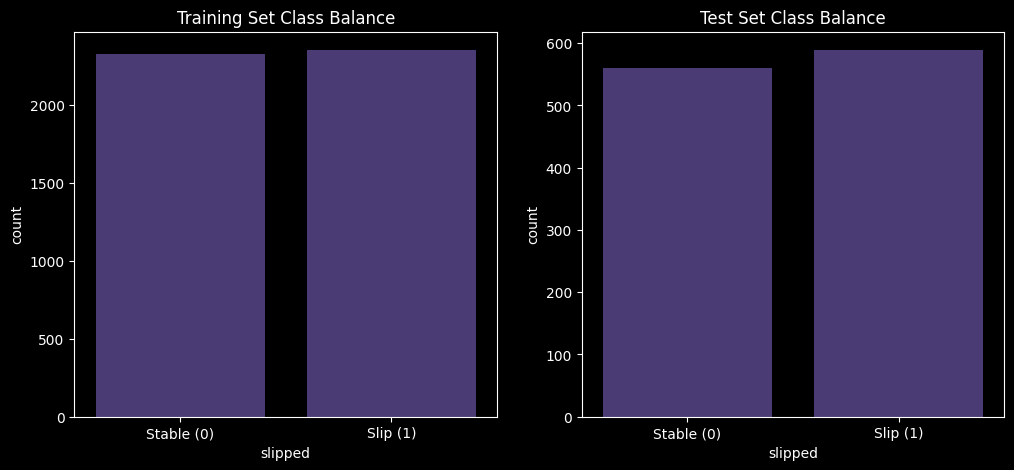

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from preprocessing.loader import load_raw
from preprocessing.pipeline import prepare_all

# Set aesthetics
plt.style.use('dark_background')
sns.set_palette("viridis")

# Load raw data
train_df, test_df = load_raw('../../data_biotac')
print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

# Distribution of the target variable
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=train_df, x='slipped', ax=ax[0])
ax[0].set_title('Training Set Class Balance')
ax[0].set_xticklabels(['Stable (0)', 'Slip (1)'])

sns.countplot(data=test_df, x='slipped', ax=ax[1])
ax[1].set_title('Test Set Class Balance')
ax[1].set_xticklabels(['Stable (0)', 'Slip (1)'])
plt.show()


## Spatial Tactile Visualisation
The BioTac sensor has 24 taxels. We can visualise the mean pressure distribution during a stable grasp versus a slip to understand what the 2D CNN is learning.


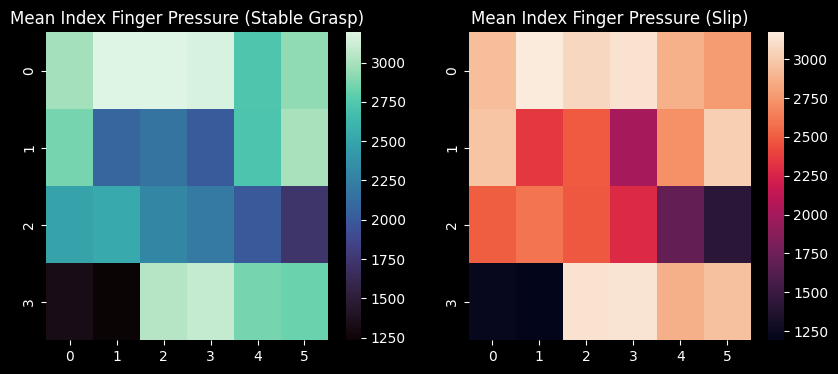

In [2]:
# Extract just the first finger (index) taxels for a stable vs slip grasp
ff_cols = [col for col in train_df.columns if 'ff_biotac' in col]

stable_mean = train_df[train_df['slipped'] == 0][ff_cols].mean().values.reshape(4, 6)
slip_mean = train_df[train_df['slipped'] == 1][ff_cols].mean().values.reshape(4, 6)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(stable_mean, cmap='mako', ax=axes[0], annot=False)
axes[0].set_title("Mean Index Finger Pressure (Stable Grasp)")

sns.heatmap(slip_mean, cmap='rocket', ax=axes[1], annot=False)
axes[1].set_title("Mean Index Finger Pressure (Slip)")
plt.show()


## Interpretable ML: Feature Importance
While Deep Learning models (CNN, BiLSTM) act as black boxes, the Random Forest model provides explicit feature importance. This helps us understand the physics of the grasp.


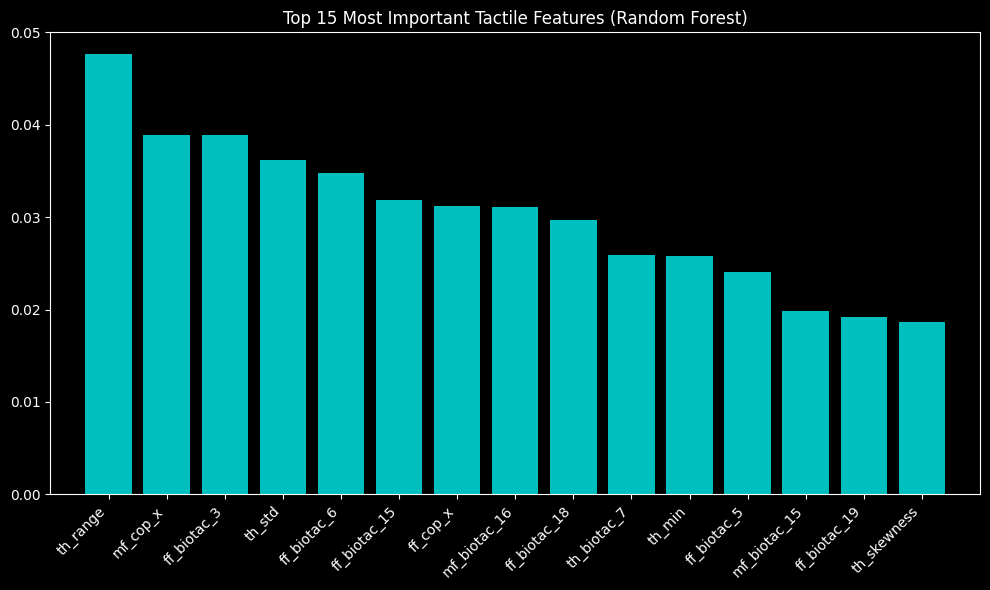

In [3]:
import joblib

# Load trained Random Forest
rf_model = joblib.load('../models/saved/random_forest.pkl')

# Get feature names from pipeline
from preprocessing.loader import get_feature_matrix, get_labels
X_train_raw = get_feature_matrix(train_df)
y_train = get_labels(train_df)
X_test_raw = get_feature_matrix(test_df)
y_test = get_labels(test_df)
data = prepare_all(X_train_raw, X_test_raw, y_train, y_test)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.title("Top 15 Most Important Tactile Features (Random Forest)")
plt.bar(range(15), importances[indices], align="center", color='c')
plt.xticks(range(15), [data.feature_names_tab[i] for i in indices], rotation=45, ha='right')
plt.xlim([-1, 15])
plt.tight_layout()
plt.show()
